In [ ]:
!pip install -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.7 MB/s eta 0:00:00


In [ ]:
# Step 1: Import Necessary Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import json

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
import keras_tuner as kt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score,precision_score,recall_score,f1_score)
import joblib

In [ ]:
# Step 2: Load the Dataset

df = pd.read_csv("/content/drive/MyDrive/NIDS_Tharusha/datasets_clean/CICIDS2017_CSE2018_merged_clean.csv")

In [ ]:
print(df.shape)

(4104990, 78)


In [ ]:
print(df["attack_family"].value_counts())

attack_family
Benign            2475643
DDoS               677759
DoS                448280
Botnet             146491
Reconnaissance     127292
Infiltration       118519
BruteForce         107933
WebAttack            3062
Exploit                11
Name: count, dtype: int64


In [ ]:
# Get the count of 'DDoS' attacks to use as the target for downsampling 'Benign'
ddos_count = df[df['attack_family'] == 'DDoS'].shape[0]

# Separate 'Benign' traffic from other attack families
df_benign = df[df['attack_family'] == 'Benign']
df_other_attacks = df[df['attack_family'] != 'Benign']

# Downsample 'Benign' traffic to match the 'DDoS' count
df_benign_downsampled = df_benign.sample(n=ddos_count, random_state=42)

# Concatenate the downsampled 'Benign' traffic with other attack families
df = pd.concat([df_benign_downsampled, df_other_attacks], axis=0)

# Display the new distribution of attack_family
print(df['attack_family'].value_counts())

attack_family
Benign            677759
DDoS              677759
DoS               448280
Botnet            146491
Reconnaissance    127292
Infiltration      118519
BruteForce        107933
WebAttack           3062
Exploit               11
Name: count, dtype: int64


In [ ]:
df = df[df["attack_family"] != "Infiltration"]


In [ ]:
df = df[df["attack_family"] != "Exploit"]


In [ ]:
df = df[df["attack_family"] != "WebAttack"]


In [ ]:
print(df["attack_family"].value_counts())

attack_family
Benign            677759
DDoS              677759
DoS               448280
Botnet            146491
Reconnaissance    127292
BruteForce        107933
Name: count, dtype: int64


In [ ]:
print(df.shape)

(2185514, 78)


In [ ]:
# Step 3: Data Exploration
# Display first few rows of the dataset
print("\nDataset Preview:")
print(df.head())

# Check dataset info
print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Preview:
         ACK Flag Count  Active Max  Active Mean  Active Min   Active Std  \
417044                0         0.0       0.0000         0.0       0.0000   
3688028               1         0.0       0.0000         0.0       0.0000   
1268926               0         0.0       0.0000         0.0       0.0000   
545523                1   1900089.0  253034.8182     21973.0  563839.9212   
1127920               0         0.0       0.0000         0.0       0.0000   

         Avg Bwd Segment Size  Avg Fwd Segment Size  Avg Packet Size  \
417044             116.000000             36.000000         85.00000   
3688028            121.333336            187.000000        162.37500   
1268926             86.000000             45.000000         76.75000   
545523             166.684211            152.611111        178.27027   
1127920             47.111111            517.285714        252.81250   

         Bwd Avg Bulk Rate  Bwd Avg Bytes/Bulk  ...  SYN Flag Count  \
417044         

In [ ]:
# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())



Statistical Summary:
       ACK Flag Count    Active Max   Active Mean    Active Min    Active Std  \
count    2.185514e+06  2.185514e+06  2.185514e+06  2.185514e+06  2.185514e+06   
mean     3.709754e-01  1.028552e+05  7.187451e+04  5.452949e+04  2.670654e+04   
std      4.830660e-01  1.217156e+06  9.146273e+05  7.781590e+05  5.240831e+05   
min      0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%      0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
50%      0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
75%      1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
max      1.000000e+00  1.060000e+08  1.030000e+08  1.030000e+08  7.490000e+07   

       Avg Bwd Segment Size  Avg Fwd Segment Size  Avg Packet Size  \
count          2.185514e+06          2.185514e+06     2.185514e+06   
mean           3.070460e+02          5.716474e+01     1.877510e+02   
std            6.119830e+02          1

In [ ]:
#Identifying duplicate values
dups = df[df.duplicated()]
print(f'Number of duplicates: {len(dups)}')

Number of duplicates: 214856


In [ ]:
# Identify duplicate values within each attack_family and count them
duplicate_counts_per_family = df.groupby('attack_family').apply(lambda x: x.duplicated().sum())
print("Duplicate counts per attack family:")
print(duplicate_counts_per_family)



Duplicate counts per attack family:
attack_family
Benign             26013
Botnet               519
BruteForce          4682
DDoS                   6
DoS                57967
Reconnaissance    125669
dtype: int64


/tmp/ipykernel_8624/3337608059.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duplicate_counts_per_family = df.groupby('attack_family').apply(lambda x: x.duplicated().sum())


In [ ]:
# Remove duplicate values only from the 'Benign' attack_family
# Separate 'Benign' from other attack families
df_benign = df[df['attack_family'] == 'Benign']
df_other_attacks = df[df['attack_family'] != 'Benign']

# Drop duplicates from the 'Benign' subset
df_benign_deduplicated = df_benign.drop_duplicates()

# Concatenate the deduplicated 'Benign' data with the other attack families
df = pd.concat([df_benign_deduplicated, df_other_attacks], axis=0)

print(f"\nShape after removing 'Benign' duplicates: {df.shape}")
print("\nNew 'attack_family' value counts:")
print(df['attack_family'].value_counts())


Shape after removing 'Benign' duplicates: (2159501, 78)

New 'attack_family' value counts:
attack_family
DDoS              677759
Benign            651746
DoS               448280
Botnet            146491
Reconnaissance    127292
BruteForce        107933
Name: count, dtype: int64


In [ ]:
#Identifying missing values
missing_val = df.isna().sum()
print(missing_val.loc[missing_val > 0])

Series([], dtype: int64)


In [ ]:
# Checking for infinity values
numeric_cols = df.select_dtypes(include = np.number).columns
inf_count = np.isinf(df[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Series([], dtype: int64)


In [ ]:
df['attack_family'].unique()

array(['Benign', 'Botnet', 'BruteForce', 'DDoS', 'DoS', 'Reconnaissance'],
      dtype=object)

In [ ]:
corr = df.corr(numeric_only = True).round(2)
corr.style.background_gradient(cmap = 'coolwarm', axis = None).format(precision = 2)

,ACK Flag Count,Active Max,Active Mean,Active Min,Active Std,Avg Bwd Segment Size,Avg Fwd Segment Size,Avg Packet Size,Bwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Header Length,Bwd IAT Max,Bwd IAT Mean,Bwd IAT Min,Bwd IAT Std,Bwd IAT Total,Bwd PSH Flags,Bwd Packet Length Max,Bwd Packet Length Mean,Bwd Packet Length Min,Bwd Packet Length Std,Bwd Packets Length Total,Bwd Packets/s,Bwd URG Flags,CWE Flag Count,Down/Up Ratio,ECE Flag Count,FIN Flag Count,Flow Bytes/s,Flow Duration,Flow IAT Max,Flow IAT Mean,Flow IAT Min,Flow IAT Std,Flow Packets/s,Fwd Act Data Packets,Fwd Avg Bulk Rate,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Header Length,Fwd IAT Max,Fwd IAT Mean,Fwd IAT Min,Fwd IAT Std,Fwd IAT Total,Fwd PSH Flags,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Min,Fwd Packet Length Std,Fwd Packets Length Total,Fwd Packets/s,Fwd Seg Size Min,Fwd URG Flags,Idle Max,Idle Mean,Idle Min,Idle Std,Init Bwd Win Bytes,Init Fwd Win Bytes,PSH Flag Count,Packet Length Max,Packet Length Mean,Packet Length Min,Packet Length Std,Packet Length Variance,RST Flag Count,SYN Flag Count,Subflow Bwd Bytes,Subflow Bwd Packets,Subflow Fwd Bytes,Subflow Fwd Packets,Total Backward Packets,Total Fwd Packets,URG Flag Count
ACK Flag Count,1.00,-0.04,-0.03,-0.02,-0.04,-0.02,-0.14,-0.11,nan,nan,nan,0.00,-0.12,-0.06,0.01,-0.14,-0.15,nan,-0.05,-0.02,-0.21,-0.05,0.00,0.04,nan,-0.01,-0.42,-0.50,-0.13,-0.00,0.20,0.29,0.37,0.33,0.17,0.07,-0.02,nan,nan,nan,0.00,0.29,0.34,0.31,0.16,0.20,0.17,-0.11,-0.14,-0.06,-0.10,-0.03,0.07,0.00,-0.01,0.28,0.28,0.27,0.07,-0.16,-0.39,-0.75,-0.05,-0.10,-0.18,-0.07,-0.00,-0.50,0.17,0.00,-0.00,-0.03,-0.02,-0.00,-0.02,0.22
Active Max,-0.04,1.00,0.94,0.74,0.77,0.01,0.05,0.01,nan,nan,nan,-0.01,0.11,0.16,0.10,0.11,0.19,nan,0.01,0.01,-0.02,0.00,0.03,-0.01,nan,-0.00,-0.03,-0.05,-0.01,-0.00,0.20,0.07,0.01,-0.02,0.06,-0.01,-0.00,nan,nan,nan,-0.01,0.07,0.01,-0.02,0.05,0.20,0.01,0.03,0.05,-0.00,0.02,0.00,-0.01,-0.01,-0.00,0.07,0.04,0.03,0.13,-0.00,0.00,0.03,0.01,0.02,-0.00,0.01,0.00,-0.05,0.01,0.03,0.04,0.00,-0.00,0.04,-0.00,-0.01
Active Mean,-0.03,0.94,1.00,0.92,0.54,0.01,0.04,0.02,nan,nan,nan,-0.02,0.11,0.15,0.10,0.10,0.13,nan,0.01,0.01,-0.02,0.01,0.04,-0.01,nan,-0.00,-0.03,-0.05,-0.01,-0.00,0.17,0.08,0.01,-0.02,0.07,-0.01,0.00,nan,nan,nan,-0.01,0.08,0.01,-0.02,0.06,0.16,0.00,0.02,0.04,0.00,0.01,0.00,-0.01,-0.02,-0.00,0.08,0.05,0.04,0.13,-0.00,0.00,0.03,0.02,0.02,0.01,0.01,0.01,-0.05,0.00,0.04,0.04,0.00,0.00,0.04,0.00,-0.00
Active Min,-0.02,0.74,0.92,1.00,0.16,0.02,0.04,0.02,nan,nan,nan,-0.02,0.08,0.11,0.07,0.07,0.09,nan,0.02,0.02,-0.02,0.02,0.05,-0.01,nan,-0.00,-0.02,-0.04,-0.01,-0.00,0.13,0.07,0.01,-0.02,0.07,-0.01,0.00,nan,nan,nan,-0.01,0.07,0.01,-0.02,0.06,0.13,0.00,0.02,0.04,0.00,0.01,-0.00,-0.01,-0.02,-0.00,0.08,0.06,0.04,0.10,-0.00,0.00,0.02,0.02,0.02,0.01,0.02,0.02,-0.04,0.00,0.05,0.05,-0.00,0.00,0.05,0.00,0.00
Active Std,-0.04,0.77,0.54,0.16,1.00,-0.01,0.03,-0.00,nan,nan,nan,0.00,0.10,0.14,0.10,0.09,0.16,nan,-0.01,-0.01,-0.01,-0.02,0.00,-0.00,nan,-0.00,-0.02,-0.03,-0.01,-0.00,0.14,0.04,-0.00,-0.01,0.03,-0.00,-0.00,nan,nan,nan,-0.00,0.04,0.00,-0.01,0.02,0.14,0.01,0.02,0.03,-0.01,0.01,0.01,-0.00,-0.00,-0.00,0.04,0.02,0.00,0.11,-0.00,0.00,0.02,-0.01,0.00,-0.01,-0.01,-0.01,-0.03,0.01,0.00,0.01,0.01,-0.00,0.01,-0.00,-0.01
Avg Bwd Segment Size,-0.02,0.01,0.01,0.02,-0.01,1.00,-0.02,0.96,nan,nan,nan,0.00,0.26,0.07,-0.04,0.27,0.19,nan,0.96,1.00,-0.08,0.96,0.01,-0.03,nan,-0.00,0.08,-0.16,0.30,-0.01,0.52,0.60,-0.01,-0.15,0.61,-0.04,-0.02,nan,nan,nan,0.00,0.60,0.11,-0.14,0.68,0.52,-0.06,0.03,-0.02,-0.06,0.02,-0.02,-0.04,0.00,-0.00,0.61,0.60,0.59,0.18,-0.06,-0.08,-0.01,0.94,0.96,-0.10,0.96,0.85,-0.16,-0.06,0.01,0.01,-0.02,-0.02,0.01,-0.02,-0.08
Avg Fwd Segment Size,-0.14,0.05,0.04,0.04,0.03,-0.02,1.00,0.16,nan,nan,nan,0.00,0.14,0.06,-0.00,0.13,0.12,nan,-0.02,-0.02,-0.04,-0.02,-0.00,-0.02,nan,-0.00,0.06,0.09,-0.00,0.04,0.03,0.01,-0.13,-0.14,0.06,-0.03,-0.01,nan,nan,nan,-0.00,0.02,-0.09,-0.13,0.08,0.03,0.05,0.90,1

In [ ]:
# Dropping columns with only one unique value
num_unique = df.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
df = df[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index(['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk',
       'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bulk Rate',
       'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk'],
      dtype='object')

In [ ]:
df.shape

(2159501, 70)

In [ ]:
# Top 20 feature selection
X = df.drop(columns=["attack_type", "attack_family"])
y = df["attack_family"]

#Random Forest needs numeric labels.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

#Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y_encoded)
#extract feature Importance
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_20_features = feature_importance.head(20)

print("Top 20 Selected Features:")
print(top_20_features)



Top 20 Selected Features:
Init Fwd Win Bytes          0.066606
Fwd Seg Size Min            0.059614
Fwd Header Length           0.054313
Init Bwd Win Bytes          0.037201
Bwd Packet Length Mean      0.031401
Bwd Packet Length Std       0.030346
Subflow Fwd Bytes           0.029945
Fwd Packet Length Max       0.029247
Fwd Packets Length Total    0.028818
Bwd Header Length           0.028427
Avg Bwd Segment Size        0.026572
Fwd Packet Length Mean      0.024608
Bwd Packets/s               0.023933
Subflow Bwd Bytes           0.023696
Avg Fwd Segment Size        0.023682
Packet Length Std           0.022600
Fwd IAT Total               0.022439
Packet Length Max           0.022422
Total Fwd Packets           0.022147
Avg Packet Size             0.019065
dtype: float64


In [ ]:
print(df["attack_family"].value_counts())

attack_family
DDoS              677759
Benign            651746
DoS               448280
Botnet            146491
Reconnaissance    127292
BruteForce        107933
Name: count, dtype: int64


In [ ]:
#Save selected feature lis
selected_features = top_20_features.index.tolist()

print("Selected feature names:")
print(selected_features)

#Create reduced dataset
X_selected = X[selected_features]

print("Reduced feature set shape:", X_selected.shape)


Selected feature names:
['Init Fwd Win Bytes', 'Fwd Seg Size Min', 'Fwd Header Length', 'Init Bwd Win Bytes', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Subflow Fwd Bytes', 'Fwd Packet Length Max', 'Fwd Packets Length Total', 'Bwd Header Length', 'Avg Bwd Segment Size', 'Fwd Packet Length Mean', 'Bwd Packets/s', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Packet Length Std', 'Fwd IAT Total', 'Packet Length Max', 'Total Fwd Packets', 'Avg Packet Size']
Reduced feature set shape: (2159501, 20)


In [ ]:
final_features = top_20_features.index.tolist()

pd.DataFrame(
    {"feature": final_features}
).to_csv("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_selected_features.csv", index=False)


In [ ]:
# Data Cleaning and Feature Engineering
# Drop irrelevant columns
selected_features = pd.read_csv("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_selected_features.csv")["feature"].tolist()

print("Selected features:", selected_features)
print("Number of features:", len(selected_features))
final_columns = selected_features + ["attack_family"]

final_df = df[final_columns]

# Check processed data
print(final_df.shape)
print(final_df.head())

final_df.to_csv("/content/drive/MyDrive/NIDS_Tharusha/datasets_clean/ClassBalanceBenign/final_training_dataset.csv", index=False)

Selected features: ['Init Fwd Win Bytes', 'Fwd Seg Size Min', 'Fwd Header Length', 'Init Bwd Win Bytes', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Subflow Fwd Bytes', 'Fwd Packet Length Max', 'Fwd Packets Length Total', 'Bwd Header Length', 'Avg Bwd Segment Size', 'Fwd Packet Length Mean', 'Bwd Packets/s', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Packet Length Std', 'Fwd IAT Total', 'Packet Length Max', 'Total Fwd Packets', 'Avg Packet Size']
Number of features: 20
(2159501, 21)
         Init Fwd Win Bytes  Fwd Seg Size Min  Fwd Header Length  \
417044                   -1                40                 80   
3688028                 237                32                168   
1268926                  -1                32                 64   
545523                  254                20                384   
1127920               29200                32                232   

         Init Bwd Win Bytes  Bwd Packet Length Mean  Bwd Packet Length Std  \
417044        

In [ ]:
# Load and Splitting the Data
df= pd.read_csv("/content/drive/MyDrive/NIDS_Tharusha/datasets_clean/ClassBalanceBenign/final_training_dataset.csv")

X = df.drop(columns=["attack_family"])
y = df["attack_family"]

#Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded)

# One-hot encode labels
num_classes = len(np.unique(y_train))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)


In [ ]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Train Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81    130349
           1       0.95      0.94      0.95     29298
           2       0.97      0.89      0.93     21587
           3       0.71      0.98      0.82    135552
           4       0.68      0.45      0.54     89656
           5       0.87      0.60      0.71     25459

    accuracy                           0.78    431901
   macro avg       0.84      0.77      0.79    431901
weighted avg       0.79      0.78      0.77    431901



In [ ]:
#Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))


Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    130349
           1       1.00      1.00      1.00     29298
           2       1.00      1.00      1.00     21587
           3       1.00      1.00      1.00    135552
           4       1.00      1.00      1.00     89656
           5       1.00      1.00      1.00     25459

    accuracy                           1.00    431901
   macro avg       1.00      1.00      1.00    431901
weighted avg       1.00      1.00      1.00    431901



In [ ]:
#Train XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(set(y_train)),
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb, average='weighted'))
print(classification_report(y_test, y_pred_xgb))


XGBoost Results:
Accuracy: 0.999499885390402
F1-score: 0.9994999192541547
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    130349
           1       1.00      1.00      1.00     29298
           2       1.00      1.00      1.00     21587
           3       1.00      1.00      1.00    135552
           4       1.00      1.00      1.00     89656
           5       1.00      1.00      1.00     25459

    accuracy                           1.00    431901
   macro avg       1.00      1.00      1.00    431901
weighted avg       1.00      1.00      1.00    431901



In [ ]:
#Train MLP model using TensorFlow
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
#Early Stopping (Prevents overfitting)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_cat)
print("Test Accuracy:", test_accuracy)

y_pred_proba = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)

print(classification_report(y_test, y_pred))



Epoch 1/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9267 - loss: 0.2299 - val_accuracy: 0.9565 - val_loss: 0.1401
Epoch 2/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9612 - loss: 0.1221 - val_accuracy: 0.9668 - val_loss: 0.1021
Epoch 3/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9698 - loss: 0.0955 - val_accuracy: 0.9760 - val_loss: 0.0840
Epoch 4/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9734 - loss: 0.0832 - val_accuracy: 0.9767 - val_loss: 0.0766
Epoch 5/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9759 - loss: 0.0770 - val_accuracy: 0.9790 - val_loss: 0.0715
Epoch 6/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9774 - loss: 0.0728 - val_accuracy: 0.9791 - val_loss: 0.0703
Epoch 7/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9783 - loss: 0.0701 - val_accuracy: 0.9779 - val_loss: 0.0730
Epoch 8/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9790 - loss: 0.0677 - 

In [ ]:
def build_mlp_model(hp):
    model = keras.Sequential()

    model.add(keras.Input(shape=(X_train_scaled.shape[1],)))

    # Tune number of hidden layers
    num_layers = hp.Int("num_layers", min_value=1, max_value=3)
    for i in range(num_layers):
        model.add(
            layers.Dense(
                units=hp.Int(
                    f"units_{i}",
                    min_value=16,
                    max_value=64,
                    step=16
                ),
                activation="relu"
            )
        )
    model.add(layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice(
                "learning_rate", [1e-2, 1e-3, 1e-4]
            )
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

tuner = kt.RandomSearch(
    build_mlp_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="tuner_dir",
    project_name="TinyML_MLP"
)

tuner.search(
    X_train_scaled,
    y_train_cat,
    epochs=20,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=3)],
    verbose=1
)
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters Found:")
print(f"Number of hidden layers: {best_hp.get('num_layers')}")
print(f"Learning rate: {best_hp.get('learning_rate')}")

for i in range(best_hp.get("num_layers")):
    print(f"Units in layer {i+1}: {best_hp.get(f'units_{i}')}")

best_model = tuner.get_best_models(num_models=1)[0]

history = best_model.fit(
    X_train_scaled,
    y_train_cat,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nClassification Report (Auto-Hyperparameter Tuned MLP):")
print(classification_report(y_test, y_pred))


Trial 10 Complete [00h 31m 34s]
val_accuracy: 0.984194815158844

Best val_accuracy So Far: 0.984194815158844
Total elapsed time: 05h 04m 55s

Best Hyperparameters Found:
Number of hidden layers: 3
Learning rate: 0.001
Units in layer 1: 32
Units in layer 2: 32
Units in layer 3: 64


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9859 - loss: 0.0440 - val_accuracy: 0.9868 - val_loss: 0.0407
Epoch 2/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9869 - loss: 0.0434 - val_accuracy: 0.9876 - val_loss: 0.0407
Epoch 3/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9872 - loss: 0.0400 - val_accuracy: 0.9877 - val_loss: 0.0371
Epoch 4/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9875 - loss: 0.0394 - val_accuracy: 0.9884 - val_loss: 0.0366
Epoch 5/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9877 - loss: 0.0387 - val_accuracy: 0.9878 - val_loss: 0.0379
Epoch 6/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9879 - loss: 0.0382 - val_accuracy: 0.9882 - val_loss: 0.0367
Epoch 7/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9880 - loss: 0.0378 - val_accuracy: 0.9884 - val_loss: 0.0400
Epoch 8/30
5399/5399 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9880 - loss: 0

In [ ]:
best_model.save("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model.keras") #MLP model


In [ ]:
joblib.dump(scaler, "/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/scaler.pkl")
joblib.dump(label_encoder, "/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/label_encoder.pkl")


['/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/label_encoder.pkl']

In [ ]:
json.dump(final_features, open("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_features.json","w"))


In [ ]:
joblib.dump(rf, "/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/Other models/random_forest_model.pkl")  #random forest model
joblib.dump(lr, "/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/Other models/logistic_regression_model.pkl")  #Logistic regression model
joblib.dump(xgb_model, "/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/Other models/xgboost_model.pkl") #XGBoost model


['/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/Other models/xgboost_model.pkl']

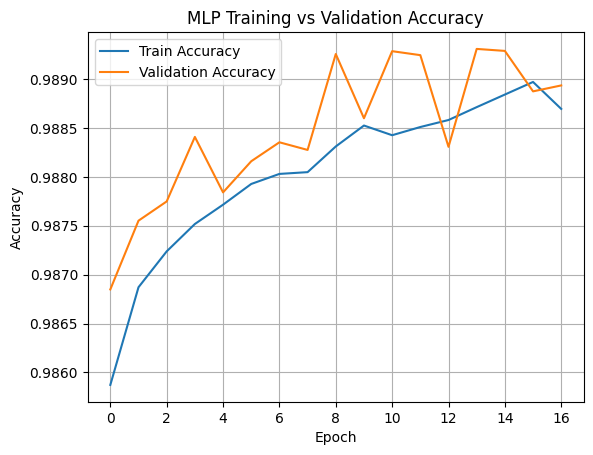

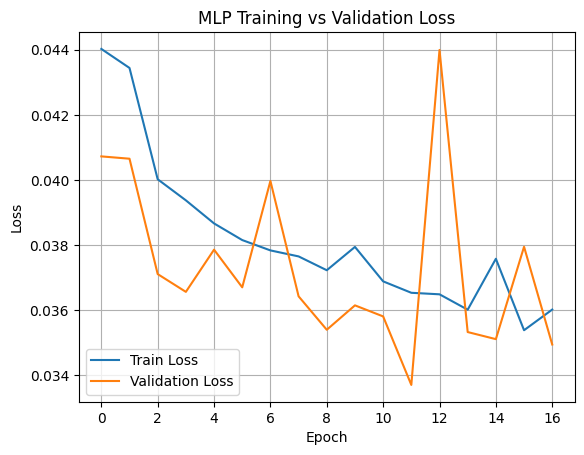

In [ ]:
# Learning Curves: Accuracy & Loss

# Accuracy
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


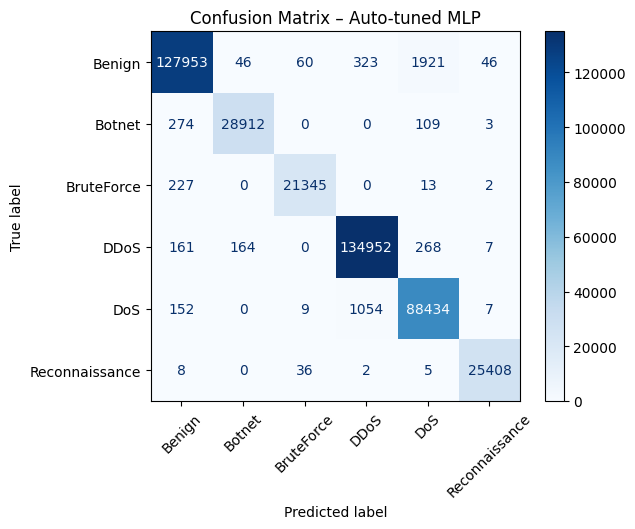

In [ ]:
#Confusion Matrix (MLP)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix – Auto-tuned MLP")
plt.show()


In [ ]:
#Model Comparison Table
results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Macro_F1": f1_score(y_test, y_pred_lr, average='macro'),
    "Model Size (MB)": os.path.getsize("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/Other models/logistic_regression_model.pkl") / (1024*1024)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Macro_F1": f1_score(y_test, y_pred_rf, average='macro'),
    "Model Size (MB)": os.path.getsize("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/Other models/random_forest_model.pkl") / (1024*1024)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Macro_F1": f1_score(y_test, y_pred_xgb, average='macro'),
    "Model Size (MB)": os.path.getsize("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/Other models/xgboost_model.pkl") / (1024*1024)
})

# MLP
results.append({
    "Model": "MLP",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Macro_F1": f1_score(y_test, y_pred, average='macro'),
    "Model Size (MB)": os.path.getsize("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model.keras") / (1024*1024)
})

comparison_df = pd.DataFrame(results)
comparison_df


,Model,Accuracy,Macro_F1,Model Size (MB)
0,Logistic Regression,0.778440,0.794104,0.001807
1,Random Forest,0.999451,0.999297,63.506951
2,XGBoost,0.999500,0.999399,2.819428
3,MLP,0.988662,0.990025,0.077419


In [ ]:
model = tf.keras.models.load_model("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved TFLite model.")


Saved artifact at '/tmp/tmp_c4_b86e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140691633057104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633057872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633057488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633053648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633058256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633058064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633056528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633058640: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved TFLite model.


In [ ]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant = converter.convert()

with open("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model_int8.tflite", "wb") as f:
    f.write(tflite_quant)
print("Saved quantized TFLite model.")


Saved artifact at '/tmp/tmpd1gz29s3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140691633057104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633057872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633057488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633053648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633058256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633058064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633056528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140691633058640: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved quantized TFLite model.


In [ ]:
#TFLite Accuracy Validation

def evaluate_tflite(tflite_path, X_test, y_test, batch_size=1024):
    # Load interpreter
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    # Input/Output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]

    # Expected input dtype/shape
    input_dtype = input_details[0]["dtype"]
    input_shape = input_details[0]["shape"]  # (1, num_features)

    num_samples = X_test.shape[0]
    preds = []

    # Run in batches (faster)
    for start in range(0, num_samples, batch_size):
        end = min(start + batch_size, num_samples)
        X_batch = X_test[start:end]

        for i in range(X_batch.shape[0]):
            x = X_batch[i].reshape(input_shape).astype(input_dtype)

            interpreter.set_tensor(input_index, x)
            interpreter.invoke()

            out = interpreter.get_tensor(output_index)  # shape (1, num_classes)
            preds.append(np.argmax(out, axis=1)[0])

    preds = np.array(preds)

    acc = accuracy_score(y_test, preds)
    print(f"\nTFLite Model: {tflite_path}")
    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    return preds, acc

# ----------------------------
# Example usage:
# IMPORTANT: Use SAME arrays you used for Keras evaluation
# X_test_scaled (float32), y_test (int labels)
# ----------------------------

# Ensure correct dtype
X_test_scaled = X_test_scaled.astype(np.float32)

# 1) Float TFLite
pred_float, acc_float = evaluate_tflite(
    "/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model.tflite",
    X_test_scaled,
    y_test
)

# 2) Quantized TFLite (Optimize.DEFAULT)
pred_int8, acc_int8 = evaluate_tflite(
    "/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model_int8.tflite",
    X_test_scaled,
    y_test
)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



TFLite Model: /content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model.tflite
Accuracy: 0.9886617535036964

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    130349
           1       0.99      0.99      0.99     29298
           2       1.00      0.99      0.99     21587
           3       0.99      1.00      0.99    135552
           4       0.97      0.99      0.98     89656
           5       1.00      1.00      1.00     25459

    accuracy                           0.99    431901
   macro avg       0.99      0.99      0.99    431901
weighted avg       0.99      0.99      0.99    431901



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



TFLite Model: /content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model_int8.tflite
Accuracy: 0.9853045026522281

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    130349
           1       0.99      0.99      0.99     29298
           2       0.99      0.99      0.99     21587
           3       0.99      0.99      0.99    135552
           4       0.97      0.98      0.98     89656
           5       1.00      1.00      1.00     25459

    accuracy                           0.99    431901
   macro avg       0.99      0.99      0.99    431901
weighted avg       0.99      0.99      0.99    431901



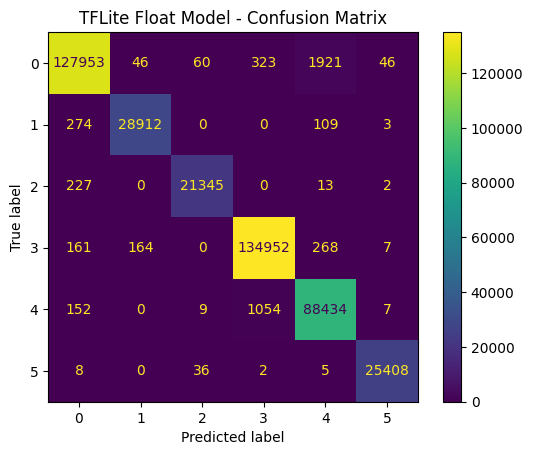

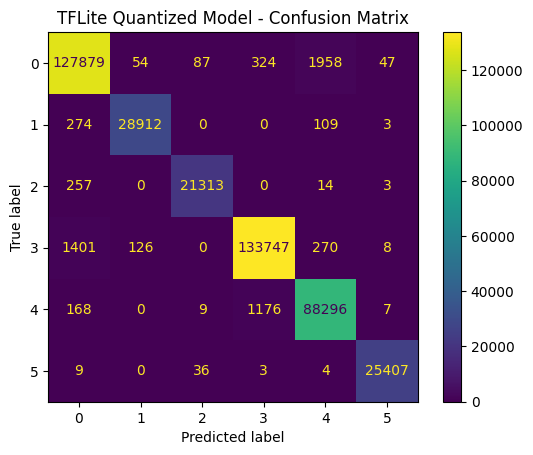

In [ ]:
def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format='d')
    plt.title(title)
    plt.show()

plot_cm(y_test, pred_float, "TFLite Float Model - Confusion Matrix")
plot_cm(y_test, pred_int8,  "TFLite Quantized Model - Confusion Matrix")


In [ ]:
keras_size_kb = os.path.getsize("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model.keras") / 1024
tflite_size_kb = os.path.getsize("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model.tflite") / 1024
int8_size_kb   = os.path.getsize("/content/drive/MyDrive/NIDS_Tharusha/models/ClassBalanceBenign/final_tinyml_mlp_model_int8.tflite") / 1024

print("\nModel Comparison")
print(f"Keras (.keras) size: {keras_size_kb:.2f} KB")
print(f"TFLite (float) size: {tflite_size_kb:.2f} KB,  Accuracy: {acc_float:.4f}")
print(f"TFLite (int8)  size: {int8_size_kb:.2f} KB,  Accuracy: {acc_int8:.4f}")



Model Comparison
Keras (.keras) size: 79.28 KB
TFLite (float) size: 18.96 KB,  Accuracy: 0.9887
TFLite (int8)  size: 11.12 KB,  Accuracy: 0.9853
